# Windonderzoek: hoe hard waait het in Nederland?

In dit notebook onderzoek je de windgegevens van het KNMI. We kijken naar de **hoogste windstoten** per dag over alle meetstations en analyseren hoe deze door de jaren veranderen.

**Wat leer je?**
- Hoe je meetdata ophaalt via de KNMI-API
- Hoe je data opschoont en analyseert met Python
- Hoe je een trendgrafiek maakt van windgegevens

> **FHX** staat voor de **windsnelheid hoogste uurgemiddelde** gemeten op een dag (in tienden van m/s, dus 253 = 25,3 m/s).

## 1: Bibliotheken en instellingen

Eerst laden we de benodigde Python-bibliotheken in. Elk pakket bevat kant-en-klare functies die we straks nodig hebben.

In [49]:
# Bibliotheken importeren
import time
import requests
import pandas as pd
import re

## 2: Instellingen

Hier stel je in van welke URL je de data ophaalt en over welke jaren.

In [50]:
# Adres van de KNMI-dataservice
URL       = "https://www.daggegevens.knmi.nl/klimatologie/daggegevens"
# Periode waarover we winddata willen ophalen
STARTJAAR = 1944
EINDJAAR  = 2026

## 3: KNMI Data downloaden.

De KNMI-website heeft een **API**: een adres waarop je automatisch data kunt opvragen. We vragen de variabele `FXX` op, de grootste windstoot per dag. Omdat er veel data is (meerdere jaren, tientallen stations), splitsen we de download op in **stukjes van een half jaar**. Zo voorkom je de je de KNMI server overbelast.

> **Let op:** Dit kan even duren. Je ziet hieronder per periode hoeveel rijen er zijn binnengekomen.

In [108]:
alle_jaren = []

# Maak een lijst van halfjaarlijkse periodes om de download op te splitsen
jaren = pd.date_range(f"{STARTJAAR}0101", f"{EINDJAAR}0101", freq="6MS").strftime("%Y%m%d").to_list()
periodes = list(zip(jaren[:-1], jaren[1:]))

for start, eind in periodes:
    # Stel de parameters in voor het API-verzoek
    params = {
        "start": start,
        "end":   eind,
        "stns":  "ALL",   # alle meetstations
        "vars":  "FHX",   # hoogste windstoot per dag
        "fmt":   "csv",
    }
    response = requests.post(URL, timeout=120, data=params)

    # Sla de periode over als de server een foutpagina teruggeeft
    if "<!DOCTYPE html>" in response.text:
        continue

    # Verwijder commentaarregels (#) en zet elke rij om naar een DataFrame
    regels = [[v.strip() for v in r.split(",")] for r in response.text.splitlines() if not r.startswith("#") and r.strip()]
    chunk = pd.DataFrame(regels, columns=["stn", "datum", "FHX"])
    alle_jaren.append(chunk)


    print(f"{start} → {eind}: {len(chunk):,} rijen")
    time.sleep(0.2)
print("Klaar! De data is gedownload.")

## 4: Alle Data samenvoegen

We hebben de data opgeslagen als losse stukken. Met `pd.concat()` plakken we die aan elkaar tot één grote tabel.

In [110]:
# Alle losse stukken samenvoegen tot één grote DataFrame
df = pd.concat(alle_jaren,ignore_index=True)
print(f"Totaal aantal rijen: {len(df):,}")
df.tail(3)

Totaal aantal rijen: 857,863


,stn,datum,FHX
857860,392,20251230,30
857861,392,20251231,40
857862,392,20260101,80


## 5: Data opschonen

De ruwe KNMI-data heeft een paar eigenaardigheden die we corrigeren:

1. **Datums omzetten** — de kolom `date` staat als getal (`20240715`), we maken er een datum object van
2. **Kolommen hernoemen** — duidelijke namen voor station, datum en windstoot
3. **FHX omzetten** — de wind uurgemiddelde staat in *tienden van m/s* (bijv. `253` = 25,3 m/s)
4. **Sorteren** op station en datum

In [111]:
# Datumkolom omzetten van tekst naar een echt datumobject
df["datum"] = pd.to_datetime(df["datum"], format="%Y%m%d")
# FXX staat in tienden van m/s, omzetten naar m/s gebeurt later bij het plotten
df["FHX"] = pd.to_numeric(df["FHX"], errors="coerce")
# Sorteren op station en datum voor overzicht
df = df.sort_values(["stn", "datum"]).reset_index(drop=True)
df.head(10)

,stn,datum,FHX
0,209,2001-01-30,NaN
1,209,2001-01-31,NaN
2,209,2001-02-01,50.0
3,209,2001-02-02,80.0
4,209,2001-02-03,90.0
5,209,2001-02-04,110.0
6,209,2001-02-05,140.0
7,209,2001-02-06,150.0
8,209,2001-02-07,120.0
9,209,2001-02-08,140.0


## 6: Stationnamen toevoegen

De KNMI-data gebruikt **stationnummers** (zoals `260` voor De Bilt). We doen één extra verzoek aan de KNMI-server en lezen de commentaarregels uit (die beginnen met `#`) om de bijbehorende namen op te zoeken.

In [112]:
# Eén verzoek om de lijst met stationnamen op te halen
response_namen = requests.post(URL, data={
    "start": "20250101", "end": "20250102",
    "stns": "ALL", "vars": "FHX", "fmt": "csv"
})
# Commentaarregels met patroon '# 260  ...' bevatten het stationnummer en de naam
station_namen = {n.split()[1]: " ".join(n.split()[5:]) for n in response_namen.text.splitlines() if re.match(r"#\s\d{3}", n)}
df["station_naam"] = df["stn"].map(station_namen)

df.head(3)

,stn,datum,FHX,station_naam
0,209,2001-01-30,NaN,IJmond
1,209,2001-01-31,NaN,IJmond
2,209,2001-02-01,50.0,IJmond


## 7: Opslaan als CSV

We slaan de opgeschoonde data op als CSV-bestand, zodat we het later opnieuw kunnen inladen zonder alles opnieuw te downloaden.

> CSV is leesbaar in Excel en elke teksteditor, maar datatypes zoals datum gaan verloren bij opnieuw inladen, vandaar de conversie in stap 8.

In [113]:
# Opslaan als CSV voor hergebruik — zo hoef je de data niet opnieuw te downloaden
df.to_csv("knmi_windsnelheid.csv", index=False)
print("Opgeslagen als knmi_windsnelheid.csv")

Opgeslagen als knmi_windsnelheid.csv


## 8: Grafiek maken

We laden het opgeslagen CSV-bestand opnieuw in en maken een grafiek van de **maximale windstoot per jaar** in Nederland. Een trendlijn laat zien hoe de windkracht zich door de jaren heen ontwikkelt.

### 8a: Data laden

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV opnieuw inladen
pad = "/Users/hbraakmann/Desktop/knmi_wind/knmi_windsnelheid.csv"
df = pd.read_csv(pad)
# Datumkolom omzetten naar datetime-object
df["datum"] = pd.to_datetime(df["datum"])
# FXX omzetten van tienden van m/s naar m/s
df["FHX"] = df["FHX"]/10

In [57]:
df["FHX"].max()

np.float64(35.0)

### 8b: Data filteren

We groeperen de data per jaar en nemen de **hoogste windstoot** die in dat jaar ergens in Nederland is gemeten.

In [115]:
# Hoogste windstoot per jaar over alle stations bepalen

# Filter op zware stormen
dag_max = df.groupby(df["datum"].dt.year)["FHX"].max().reset_index() #Filter wind maximale uurgemiddelde per jaar

In [116]:
dag_max

,datum,FHX
0,1944,35.0
1,1945,23.1
2,1946,23.7
3,1947,22.1
4,1948,21.6
...,...,...
78,2022,28.0
79,2023,30.0
80,2024,26.0
81,2025,24.0


### 8c: Data plotten

We maken een **staafdiagram** van de jaarlijkse maximale windstoot. De rode lijn is een **lineaire trendlijn** — die laat zien of de windstoten over de jaren toe- of afnemen.

> **Denkvraag:** Wat zou het betekenen als de trendlijn stijgt? En wat zijn mogelijke verklaringen?

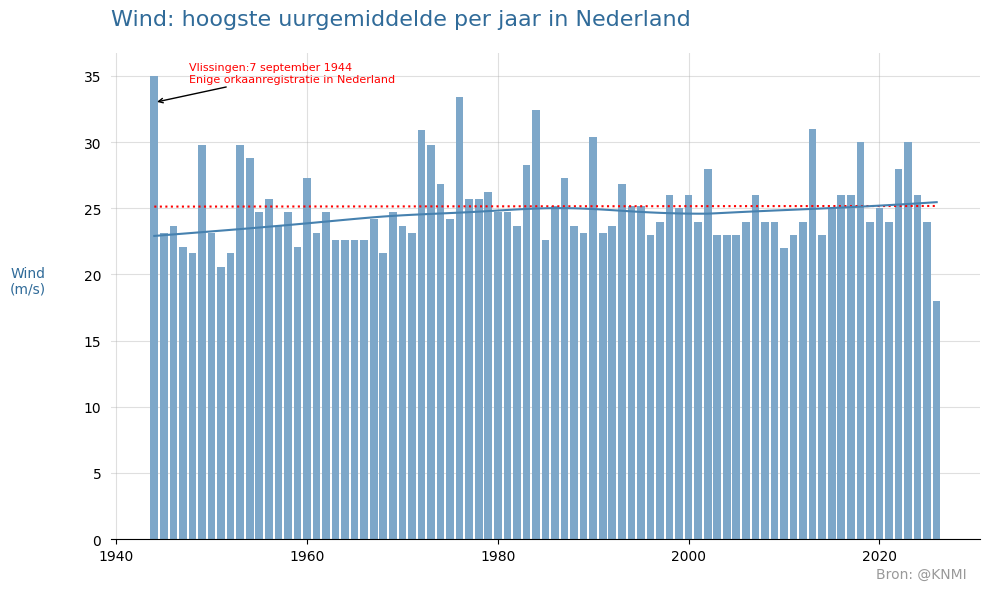

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# lewess trend
trend_low = lowess(dag_max["FHX"], dag_max["datum"], frac = 0.6)

# Lineaire trendlijn berekenen
coef = np.polyfit(dag_max["datum"], dag_max["FHX"], deg=1)
trend = np.poly1d(coef)

fig, ax = plt.subplots(figsize=(10,6))

# Staafdiagram van de jaarlijkse maximale windstoot en rode trendlijn
ax.bar(dag_max["datum"], dag_max["FHX"], color="#7DA7C9", zorder=2)
ax.plot(dag_max["datum"], trend(dag_max["datum"]), color="red", linestyle=":", zorder=2)
ax.plot(trend_low[:,0],trend_low[:,1], color="#4681AF", zorder=2)

ax.set_title("Wind: hoogste uurgemiddelde per jaar in Nederland", color="#306B99", fontsize=16, loc="left", pad=20)

ax.set_ylabel("Wind\n(m/s)", color="#306B99", rotation=0, labelpad=40)
ax.tick_params(axis="y", width=0)
ax.grid(axis="both", alpha=0.4, zorder=1)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.annotate(
    text="Vlissingen:7 september 1944\nEnige orkaanregistratie in Nederland",
    xy=(1944, dag_max["FHX"].max()-2),
    xytext=(25, 15),
    textcoords="offset points",
    fontsize=8,
    color="red",
    arrowprops = dict(arrowstyle="->"))

ax.text(0.88, -0.08, "Bron: @KNMI", transform=ax.transAxes, color="grey", alpha=0.8)

plt.tight_layout()
plt.savefig("wind.png")
plt.show()